# 04 日内季节性与去季节化

本 Notebook 从正式 silver 独立重算固定三个月合约的 5、15、30、60 分钟收益，按论文公式 (11) 估计槽位周期因子，按公式 (12) 去季节化，并验证收益与平方尺度重新季节化。全文样本因子是论文基线；另计算严格只使用当前观察以前历史的扩展因子敏感性。

本项不依赖前序 Notebook 输出，不调用 API，不读写项目缓存，不写 silver 或 gold。AL、CU、FU 是论文品种；RB 始终作为论文外扩展单列；FU 两个制度阶段不连接。

## 1. 在做什么，以及经济意义

日内收益的方差通常随交易时段呈现稳定周期，例如开盘信息集中、休市前后重新定价或收盘调整。若直接把这种确定性时段结构交给 GARCH，模型可能把“每天同一槽位都更活跃”误认为随机波动持续性。

本项把每个收益拆成：

- 可重复的槽位尺度 `S_n`；
- 去季节化后的随机部分 `r_tilde[t,n] = r[t,n] / S_n`。

经济上，`S_n` 描述同一频率内不同时段的典型波动强度；去季节化收益才是后续盘中 GARCH 家族模型的输入。重新预测到原收益尺度时，条件方差应乘 `S_n^2`。

## 2. 论文公式、实现口径与复现等级

论文公式 (11)–(13)：

- `S_n^2 = mean_t(r[t,n]^2)`；
- `r_tilde[t,n] = r[t,n] / S_n`；
- `h[t,n] = S_n^2 * h_tilde[t,n]`。

论文以完整样本估计每个日内槽位的周期因子。该做法让样本早期观察使用了未来日期，因此在预测语境中具有前视性；本项目保留它作为论文基线，同时构造严格历史因子：

- 当前观察的历史因子只使用同一“序列 × 频率 × 槽位”此前日期的平方收益；
- 首个观察没有历史因子，历史全为零时因子可以为零且不用于除法；
- 报告时以至少 60 个先前观察作为稳定敏感性子样本，但不改变全文样本基线或后续论文复现口径。

30、60 分钟末槽分别只有 15、45 个真实分钟；公式 (11) 会同时吸收其时长差异与时段效应。图形用 `S_n / mean_slot(S_n)` 只比较曲线形状，模型使用未归一化的原始 `S_n`。

**复现等级：论文方法框架复现。** 数据源、样本期、真实日盘长度、FU 分段和 RB 扩展均与论文原样本不同。

In [1]:
from __future__ import annotations

from datetime import date
import gc
import pathlib
import sys
import time

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        sys.path.insert(0, str(candidate_root / "02_Futures_Lakehouse"))
        project_root = candidate_root
        break
else:
    raise RuntimeError("未找到项目根目录")

expected_python = pathlib.Path(r"E:\anaconda3\envs\latitude\python.exe").resolve()
current_python = pathlib.Path(sys.executable).resolve()
assert current_python == expected_python, (
    f"必须使用 latitude 环境解释器 {expected_python}，实际为 {current_python}"
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
from IPython.display import Markdown, display
from scipy.stats import kurtosis, skew

from config.data_contracts import (
    FUTURES_BAR_CALENDAR_SCHEMA,
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_MINUTE_SCHEMA,
    FUTURES_VARIETY_CALENDAR_SCHEMA,
    arrow_to_pandas,
    validate_arrow_table,
)
from a00_03_notebook_schema_browser import display_schema_metadata
from config.settings import settings

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 200)

print(f"Python: {sys.executable}")
print(f"项目根目录: {project_root}")
print(f"正式湖仓根目录: {settings.futures_lake_root}")

Python: E:\anaconda3\envs\latitude\python.exe
项目根目录: E:\Latitude_Analytics_v2
正式湖仓根目录: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake


## 3. 开篇 Schema metadata 浏览器

直接参与本项的四张权威表是品种交易日、合约 Session 日历、一分钟抓取/质量日历和一分钟事实。先展示契约，再读取业务数据。

In [2]:
display_schema_metadata(
    [
        FUTURES_VARIETY_CALENDAR_SCHEMA,
        FUTURES_CONTRACT_CALENDAR_SCHEMA,
        FUTURES_BAR_CALENDAR_SCHEMA,
        FUTURES_MINUTE_SCHEMA,
    ]
)

英文表名,中文表名,字段数,主键,Hive 分区,Schema 版本
dim_futures_variety_calendar,期货品种交易日历维度表,8,"exchange_code,underlying_code,trading_date","exchange_code,year,month",1.2.0
dim_futures_contract_calendar,期货合约 Session 日历维度表,21,"contract_code,trading_date,session_number","exchange_code,year,month",1.2.0
dim_futures_bar_calendar,期货行情拉取与质检日历维度表,48,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",1.4.0
fact_futures_minute,国内期货合约一分钟行情事实表,17,"contract_code,bar_at","exchange_code,underlying_code,year,month",1.5.0


## 4. 参数、固定样本与代码步骤

代码保持自包含并从上到下执行：

1. 冻结五个研究序列、样本端点和 5/15/30/60 分钟槽位；
2. 从 Schema metadata 打开四张正式表并核对物理兼容性；
3. 重建交易月后第 3 个月交割的固定月份合约链；
4. 用 bar calendar 选择三个完整日盘 Session，并以精确键排除分钟事实中的夜盘；
5. Session 内构造一分钟收益，按全日真实交易分钟序号聚合多尺度收益；
6. 估计全文样本 `S_n`、去季节化并验证重新季节化；
7. 构造严格历史扩展因子并量化与全文样本因子的差异；
8. 展示周期曲线、槽位峰谷、末槽效应、覆盖与独立门禁。

In [3]:
exchange_code = "XSGE"
sample_start = date(2010, 1, 4)
sample_end = date(2026, 8, 28)
zero_return_tolerance = 1e-12
sensitivity_min_prior_observations = 60

sample_spec_df = pd.DataFrame(
    [
        ("AL", "AL", date(2010, 1, 4), date(2026, 8, 28), "论文品种"),
        ("CU", "CU", date(2010, 1, 4), date(2026, 8, 28), "论文品种"),
        ("FU_legacy", "FU", date(2010, 1, 4), date(2011, 9, 30), "论文品种：旧产品段"),
        ("FU_relaunched", "FU", date(2020, 1, 2), date(2026, 8, 28), "论文品种：稳定重启段"),
        ("RB", "RB", date(2010, 1, 4), date(2026, 8, 28), "论文外扩展品种"),
    ],
    columns=[
        "series_id",
        "underlying_code",
        "sample_start",
        "sample_end",
        "research_role",
    ],
)
sample_spec_df["sample_start"] = pd.to_datetime(sample_spec_df["sample_start"])
sample_spec_df["sample_end"] = pd.to_datetime(sample_spec_df["sample_end"])
series_order = sample_spec_df["series_id"].tolist()

interval_spec_df = pd.DataFrame(
    [
        ("5-min", 5, 45, 5),
        ("15-min", 15, 15, 15),
        ("30-min", 30, 8, 15),
        ("60-min", 60, 4, 45),
    ],
    columns=[
        "interval_label",
        "target_interval_minutes",
        "expected_daily_slots",
        "expected_last_slot_minutes",
    ],
)
interval_order = interval_spec_df["interval_label"].tolist()
display(sample_spec_df)
display(interval_spec_df)

,series_id,underlying_code,sample_start,sample_end,research_role
0,AL,AL,2010-01-04,2026-08-28,论文品种
1,CU,CU,2010-01-04,2026-08-28,论文品种
2,FU_legacy,FU,2010-01-04,2011-09-30,论文品种：旧产品段
3,FU_relaunched,FU,2020-01-02,2026-08-28,论文品种：稳定重启段
4,RB,RB,2010-01-04,2026-08-28,论文外扩展品种


,interval_label,target_interval_minutes,expected_daily_slots,expected_last_slot_minutes
0,5-min,5,45,5
1,15-min,15,15,15
2,30-min,30,8,15
3,60-min,60,4,45


## 5. 直接 PyArrow 过滤读取与固定三个月合约链

表名、主键和分区顺序只从 Schema metadata 获取；字段类型与 nullable 只从权威 `pa.Schema` 获取。分钟读取按“研究序列 × 年”执行 Arrow 过滤，再与日盘 Session 键内连接。

In [4]:
source_schema_by_role = {
    "variety_calendar": FUTURES_VARIETY_CALENDAR_SCHEMA,
    "contract_calendar": FUTURES_CONTRACT_CALENDAR_SCHEMA,
    "bar_calendar": FUTURES_BAR_CALENDAR_SCHEMA,
    "minute_fact": FUTURES_MINUTE_SCHEMA,
}
source_dataset_by_role = {}
source_contract_audit_rows = []

for source_role, source_schema in source_schema_by_role.items():
    source_metadata = {
        key.decode("utf-8"): value.decode("utf-8")
        for key, value in source_schema.metadata.items()
    }
    table_name = source_metadata["table_name"]
    primary_key = source_metadata["primary_key"].split(",")
    partition_columns = source_metadata["partition_columns"].split(",")
    table_path = settings.futures_lake_root / "silver" / table_name
    partitioning = ds.partitioning(
        pa.schema(
            [source_schema.field(column_name) for column_name in partition_columns]
        ),
        flavor="hive",
    )
    source_dataset = ds.dataset(
        table_path,
        format="parquet",
        partitioning=partitioning,
    )

    physical_mismatches = []
    for expected_field in source_schema:
        actual_field = source_dataset.schema.field(expected_field.name)
        if (
            actual_field.type != expected_field.type
            or actual_field.nullable != expected_field.nullable
        ):
            physical_mismatches.append(
                {
                    "field": expected_field.name,
                    "expected_type": str(expected_field.type),
                    "actual_type": str(actual_field.type),
                    "expected_nullable": expected_field.nullable,
                    "actual_nullable": actual_field.nullable,
                }
            )
    if physical_mismatches:
        raise TypeError({table_name: physical_mismatches})

    source_dataset_by_role[source_role] = source_dataset
    source_contract_audit_rows.append(
        {
            "source_role": source_role,
            "table_name": table_name,
            "primary_key": ",".join(primary_key),
            "partition_columns": ",".join(partition_columns),
            "physical_mismatch_count": len(physical_mismatches),
        }
    )

source_contract_audit_df = pd.DataFrame(source_contract_audit_rows)
display(source_contract_audit_df)

,source_role,table_name,primary_key,partition_columns,physical_mismatch_count
0,variety_calendar,dim_futures_variety_calendar,"exchange_code,underlying_code,trading_date","exchange_code,year,month",0
1,contract_calendar,dim_futures_contract_calendar,"contract_code,trading_date,session_number","exchange_code,year,month",0
2,bar_calendar,dim_futures_bar_calendar,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",0
3,minute_fact,fact_futures_minute,"contract_code,bar_at","exchange_code,underlying_code,year,month",0


In [5]:
trading_date_field = ds.field("trading_date")
underlying_field = ds.field("underlying_code")
base_filter = (
    (ds.field("exchange_code") == exchange_code)
    & (ds.field("year") >= sample_start.year)
    & (ds.field("year") <= sample_end.year)
)
main_series_filter = (
    underlying_field.isin(["AL", "CU", "RB"])
    & (trading_date_field >= pa.scalar(sample_start, type=pa.date32()))
    & (trading_date_field <= pa.scalar(sample_end, type=pa.date32()))
)
fu_series_filter = (
    (underlying_field == "FU")
    & (
        (
            (trading_date_field >= pa.scalar(date(2010, 1, 4), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2011, 9, 30), type=pa.date32()))
        )
        | (
            (trading_date_field >= pa.scalar(date(2020, 1, 2), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2026, 8, 28), type=pa.date32()))
        )
    )
)
research_sample_filter = base_filter & (main_series_filter | fu_series_filter)

variety_columns = [
    "underlying_code",
    "exchange_code",
    "trading_date",
    "active_contract_count",
]
variety_projection_schema = pa.schema(
    [
        FUTURES_VARIETY_CALENDAR_SCHEMA.field(column_name)
        for column_name in variety_columns
    ]
)
variety_calendar_table = source_dataset_by_role["variety_calendar"].to_table(
    columns=variety_columns,
    filter=research_sample_filter,
)
validated_variety_calendar_table = validate_arrow_table(
    variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df = arrow_to_pandas(
    validated_variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df["trading_date"] = pd.to_datetime(
    variety_calendar_df["trading_date"]
)

expected_sample_pieces = []
for sample_spec in sample_spec_df.itertuples(index=False):
    expected_series_df = variety_calendar_df.loc[
        (variety_calendar_df["underlying_code"] == sample_spec.underlying_code)
        & (variety_calendar_df["trading_date"] >= sample_spec.sample_start)
        & (variety_calendar_df["trading_date"] <= sample_spec.sample_end)
    ].copy()
    expected_series_df.insert(0, "series_id", sample_spec.series_id)
    expected_sample_pieces.append(expected_series_df)

expected_sample_df = pd.concat(
    expected_sample_pieces,
    ignore_index=True,
).sort_values(["series_id", "trading_date"], ignore_index=True)

target_delivery_period = (
    pd.PeriodIndex(expected_sample_df["trading_date"], freq="M") + 3
)
expected_sample_df["target_delivery_year"] = target_delivery_period.year
expected_sample_df["target_delivery_month"] = target_delivery_period.month
expected_sample_df["expected_contract_code"] = (
    expected_sample_df["underlying_code"].astype("string")
    + expected_sample_df["target_delivery_year"].mod(100).astype("string").str.zfill(2)
    + expected_sample_df["target_delivery_month"].astype("string").str.zfill(2)
    + "."
    + expected_sample_df["exchange_code"].astype("string")
)

display(
    expected_sample_df.groupby("series_id", observed=True)["trading_date"]
    .agg(
        expected_trading_days="size",
        first_date="min",
        last_date="max",
    )
    .reset_index()
)

,series_id,expected_trading_days,first_date,last_date
0,AL,4045,2010-01-04,2026-08-28
1,CU,4045,2010-01-04,2026-08-28
2,FU_legacy,426,2010-01-04,2011-09-30
3,FU_relaunched,1614,2020-01-02,2026-08-28
4,RB,4045,2010-01-04,2026-08-28


In [6]:
contract_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "session_start_at",
    "session_end_at",
    "is_night_session",
    "minute_count",
]
contract_projection_schema = pa.schema(
    [
        FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name)
        for column_name in contract_columns
    ]
)
day_contract_filter = research_sample_filter & (
    ds.field("is_night_session") == False
)
contract_calendar_table = source_dataset_by_role["contract_calendar"].to_table(
    columns=contract_columns,
    filter=day_contract_filter,
)
validated_contract_calendar_table = validate_arrow_table(
    contract_calendar_table,
    contract_projection_schema,
)
contract_calendar_df = arrow_to_pandas(
    validated_contract_calendar_table,
    contract_projection_schema,
)
contract_calendar_df["trading_date"] = pd.to_datetime(
    contract_calendar_df["trading_date"]
)

contract_code_parts = contract_calendar_df["contract_code"].astype("string").str.extract(
    r"^([A-Z]+)(\d{4})\.([A-Z]+)$"
)
if not contract_code_parts.notna().all().all():
    invalid_contract_codes = contract_calendar_df.loc[
        contract_code_parts.isna().any(axis=1),
        "contract_code",
    ].drop_duplicates()
    raise ValueError(
        f"发现无法解析的固定月份合约代码: {invalid_contract_codes.tolist()}"
    )

contract_calendar_df["code_underlying"] = contract_code_parts[0]
contract_calendar_df["delivery_year"] = (
    2000 + contract_code_parts[1].str[:2].astype("int16")
)
contract_calendar_df["delivery_month"] = (
    contract_code_parts[1].str[2:].astype("int8")
)
contract_calendar_df["code_exchange"] = contract_code_parts[2]
trade_plus_three_period = (
    pd.PeriodIndex(contract_calendar_df["trading_date"], freq="M") + 3
)
contract_calendar_df["is_target_delivery"] = (
    contract_calendar_df["delivery_year"].eq(trade_plus_three_period.year)
    & contract_calendar_df["delivery_month"].eq(trade_plus_three_period.month)
)

assert (
    contract_calendar_df["code_underlying"]
    == contract_calendar_df["underlying_code"]
).all()
assert (
    contract_calendar_df["code_exchange"]
    == contract_calendar_df["exchange_code"]
).all()
assert not contract_calendar_df["is_night_session"].any()

target_session_df = contract_calendar_df.loc[
    contract_calendar_df["is_target_delivery"]
].copy()
target_contract_count_df = (
    target_session_df.groupby(
        ["underlying_code", "trading_date"],
        observed=True,
    )["contract_code"]
    .nunique()
    .rename("target_contract_count")
    .reset_index()
)
target_contract_day_df = (
    target_session_df.groupby(
        [
            "underlying_code",
            "trading_date",
            "contract_code",
            "delivery_year",
            "delivery_month",
        ],
        observed=True,
        sort=True,
    )
    .agg(
        day_session_count=("session_number", "nunique"),
        day_minute_count=("minute_count", "sum"),
    )
    .reset_index()
)

contract_mapping_audit_df = expected_sample_df.merge(
    target_contract_count_df,
    on=["underlying_code", "trading_date"],
    how="left",
    validate="one_to_one",
)
contract_mapping_audit_df["target_contract_count"] = (
    contract_mapping_audit_df["target_contract_count"]
    .fillna(0)
    .astype("int64")
)
assert contract_mapping_audit_df["target_contract_count"].le(1).all()

contract_mapping_audit_df = contract_mapping_audit_df.merge(
    target_contract_day_df,
    on=["underlying_code", "trading_date"],
    how="left",
    validate="one_to_one",
)
contract_mapping_audit_df["mapping_status"] = np.where(
    contract_mapping_audit_df["contract_code"].notna(),
    "selected",
    "excluded_target_contract_not_listed",
)
missing_contract_mapping_df = contract_mapping_audit_df.loc[
    contract_mapping_audit_df["mapping_status"] != "selected",
    [
        "series_id",
        "trading_date",
        "expected_contract_code",
        "target_contract_count",
        "mapping_status",
    ],
].copy()

known_missing_keys_df = expected_sample_df.loc[
    (expected_sample_df["series_id"] == "FU_legacy")
    & (
        expected_sample_df["trading_date"].dt.to_period("M")
        == pd.Period("2010-11")
    ),
    ["series_id", "trading_date", "expected_contract_code"],
].sort_values(["series_id", "trading_date"], ignore_index=True)
actual_missing_keys_df = missing_contract_mapping_df[
    ["series_id", "trading_date", "expected_contract_code"]
].sort_values(["series_id", "trading_date"], ignore_index=True)
assert actual_missing_keys_df.equals(known_missing_keys_df)
assert set(actual_missing_keys_df["expected_contract_code"]) == {
    "FU1102.XSGE"
}

contract_series_df = contract_mapping_audit_df.loc[
    contract_mapping_audit_df["mapping_status"] == "selected"
].copy()
contract_series_df = contract_series_df.sort_values(
    ["series_id", "trading_date"],
    ignore_index=True,
)
contract_series_df["previous_contract_code"] = (
    contract_series_df.groupby(
        "series_id",
        observed=True,
    )["contract_code"].shift()
)
contract_series_df["is_roll_day"] = (
    contract_series_df["previous_contract_code"].notna()
    & contract_series_df["contract_code"].ne(
        contract_series_df["previous_contract_code"]
    )
).astype("bool")

selected_target_session_df = target_session_df.merge(
    contract_series_df[
        [
            "series_id",
            "underlying_code",
            "trading_date",
            "contract_code",
            "delivery_year",
            "delivery_month",
            "is_roll_day",
        ]
    ],
    on=[
        "underlying_code",
        "trading_date",
        "contract_code",
        "delivery_year",
        "delivery_month",
    ],
    how="inner",
    validate="many_to_one",
)
assert selected_target_session_df.groupby(
    ["series_id", "trading_date"],
    observed=True,
)["session_number"].nunique().eq(3).all()

display(missing_contract_mapping_df)
display(
    contract_series_df.groupby("series_id", observed=True)
    .agg(
        selected_trading_days=("trading_date", "size"),
        first_selected_date=("trading_date", "min"),
        last_selected_date=("trading_date", "max"),
        unique_contracts=("contract_code", "nunique"),
        roll_days=("is_roll_day", "sum"),
    )
    .reset_index()
)

,series_id,trading_date,expected_contract_code,target_contract_count,mapping_status
8287,FU_legacy,2010-11-01,FU1102.XSGE,0,excluded_target_contract_not_listed
8288,FU_legacy,2010-11-02,FU1102.XSGE,0,excluded_target_contract_not_listed
8289,FU_legacy,2010-11-03,FU1102.XSGE,0,excluded_target_contract_not_listed
8290,FU_legacy,2010-11-04,FU1102.XSGE,0,excluded_target_contract_not_listed
8291,FU_legacy,2010-11-05,FU1102.XSGE,0,excluded_target_contract_not_listed
8292,FU_legacy,2010-11-08,FU1102.XSGE,0,excluded_target_contract_not_listed
8293,FU_legacy,2010-11-09,FU1102.XSGE,0,excluded_target_contract_not_listed
8294,FU_legacy,2010-11-10,FU1102.XSGE,0,excluded_target_contract_not_listed
8295,FU_legacy,2010-11-11,FU1102.XSGE,0,excluded_target_contract_not_listed
8296,FU_legacy,2010-11-12,FU1102.XSGE,0,excluded_target_contract_not_listed


,series_id,selected_trading_days,first_selected_date,last_selected_date,unique_contracts,roll_days
0,AL,4045,2010-01-04,2026-08-28,200,199
1,CU,4045,2010-01-04,2026-08-28,200,199
2,FU_legacy,404,2010-01-04,2011-09-30,20,19
3,FU_relaunched,1614,2020-01-02,2026-08-28,80,79
4,RB,4045,2010-01-04,2026-08-28,200,199


In [7]:
bar_columns = [
    "bar_frequency",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "is_night_session",
    "is_fetch_required",
    "expected_bar_count",
    "is_fetch_completed",
    "actual_bar_count",
    "missing_bar_count",
]
bar_projection_schema = pa.schema(
    [FUTURES_BAR_CALENDAR_SCHEMA.field(column_name) for column_name in bar_columns]
)
day_bar_filter = (
    research_sample_filter
    & (ds.field("bar_frequency") == "1m")
    & (ds.field("is_night_session") == False)
)
bar_calendar_table = source_dataset_by_role["bar_calendar"].to_table(
    columns=bar_columns,
    filter=day_bar_filter,
)
validated_bar_calendar_table = validate_arrow_table(
    bar_calendar_table,
    bar_projection_schema,
)
bar_calendar_df = arrow_to_pandas(
    validated_bar_calendar_table,
    bar_projection_schema,
)
bar_calendar_df["trading_date"] = pd.to_datetime(
    bar_calendar_df["trading_date"]
)

bar_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
selected_bar_session_df = selected_target_session_df[
    [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "session_number",
        "delivery_year",
        "delivery_month",
        "is_roll_day",
        "minute_count",
    ]
].merge(
    bar_calendar_df,
    on=bar_join_key,
    how="left",
    validate="one_to_one",
    indicator=True,
)
selected_bar_session_df["eligible_session"] = (
    selected_bar_session_df["_merge"].eq("both")
    & selected_bar_session_df["is_fetch_required"].eq(True)
    & selected_bar_session_df["is_fetch_completed"].eq(True)
    & selected_bar_session_df["expected_bar_count"].eq(
        selected_bar_session_df["actual_bar_count"]
    )
    & selected_bar_session_df["missing_bar_count"].eq(0)
)

selected_day_key = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
]
complete_contract_day_df = (
    selected_bar_session_df.groupby(
        selected_day_key,
        observed=True,
        sort=True,
    )
    .agg(
        day_session_count=("session_number", "nunique"),
        upstream_session_rows=("bar_frequency", "count"),
        eligible_session_count=("eligible_session", "sum"),
        expected_minute_rows=("expected_bar_count", "sum"),
        actual_minute_rows=("actual_bar_count", "sum"),
        missing_minute_rows=("missing_bar_count", "sum"),
    )
    .reset_index()
)
complete_contract_day_df["is_complete_contract_day"] = (
    complete_contract_day_df["day_session_count"].eq(3)
    & complete_contract_day_df["upstream_session_rows"].eq(3)
    & complete_contract_day_df["eligible_session_count"].eq(3)
    & complete_contract_day_df["expected_minute_rows"].eq(225)
    & complete_contract_day_df["actual_minute_rows"].eq(225)
    & complete_contract_day_df["missing_minute_rows"].eq(0)
)

complete_day_keys_df = complete_contract_day_df.loc[
    complete_contract_day_df["is_complete_contract_day"],
    selected_day_key,
].copy()
complete_session_keys_df = selected_bar_session_df.merge(
    complete_day_keys_df,
    on=selected_day_key,
    how="inner",
    validate="many_to_one",
)
complete_session_keys_df = complete_session_keys_df.loc[
    complete_session_keys_df["eligible_session"]
].copy()
complete_session_keys_df["calendar_year"] = (
    complete_session_keys_df["trading_date"].dt.year.astype("int16")
)

coverage_df = (
    contract_series_df.groupby("series_id", observed=True)
    .agg(selected_contract_days=("trading_date", "size"))
    .reset_index()
    .merge(
        complete_contract_day_df.groupby("series_id", observed=True)
        ["is_complete_contract_day"]
        .sum()
        .rename("complete_contract_days")
        .reset_index(),
        on="series_id",
        validate="one_to_one",
    )
)
coverage_df["complete_pct"] = (
    100
    * coverage_df["complete_contract_days"]
    / coverage_df["selected_contract_days"]
)
display(coverage_df.round(4))

,series_id,selected_contract_days,complete_contract_days,complete_pct
0,AL,4045,4045,100.0
1,CU,4045,4045,100.0
2,FU_legacy,404,404,100.0
3,FU_relaunched,1614,1614,100.0
4,RB,4045,4045,100.0


## 6. Session 内收益与日内槽位

下面重复第 03 项的直接计算而不读取其输出。每个 Session 首分钟用本 Session 开盘价锚定；多尺度槽位按 225 个真实日盘交易分钟的全日序号切分。

In [8]:
minute_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "bar_at",
    "open",
    "close",
]
minute_projection_schema = pa.schema(
    [FUTURES_MINUTE_SCHEMA.field(column_name) for column_name in minute_columns]
)
minute_session_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
minute_session_context_columns = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
    "expected_bar_count",
]
multiscale_return_pieces = []
minute_read_audit_rows = []
slot_audit_rows = []

for (
    series_id,
    calendar_year,
), partition_session_keys_df in complete_session_keys_df.groupby(
    ["series_id", "calendar_year"],
    observed=True,
    sort=True,
):
    partition_started_at = time.perf_counter()
    partition_session_keys_df = partition_session_keys_df[
        minute_session_context_columns
    ].drop_duplicates()
    assert not partition_session_keys_df.duplicated(
        minute_session_join_key
    ).any()

    underlying_codes = (
        partition_session_keys_df["underlying_code"].drop_duplicates().tolist()
    )
    assert len(underlying_codes) == 1
    underlying_code = underlying_codes[0]
    partition_first_date = partition_session_keys_df["trading_date"].min()
    partition_last_date = partition_session_keys_df["trading_date"].max()
    partition_contract_codes = (
        partition_session_keys_df["contract_code"].drop_duplicates().tolist()
    )

    minute_partition_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("underlying_code") == underlying_code)
        & (ds.field("year") == int(calendar_year))
        & ds.field("contract_code").isin(partition_contract_codes)
        & (
            ds.field("trading_date")
            >= pa.scalar(partition_first_date.date(), type=pa.date32())
        )
        & (
            ds.field("trading_date")
            <= pa.scalar(partition_last_date.date(), type=pa.date32())
        )
    )
    minute_partition_table = source_dataset_by_role["minute_fact"].to_table(
        columns=minute_columns,
        filter=minute_partition_filter,
    )
    validated_minute_partition_table = validate_arrow_table(
        minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df = arrow_to_pandas(
        validated_minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df["trading_date"] = pd.to_datetime(
        minute_partition_df["trading_date"]
    )

    selected_minute_df = minute_partition_df.merge(
        partition_session_keys_df,
        on=minute_session_join_key,
        how="inner",
        validate="many_to_one",
    )
    selected_minute_df = selected_minute_df.sort_values(
        [
            "series_id",
            "trading_date",
            "contract_code",
            "bar_at",
        ],
        ignore_index=True,
    )
    for price_column in ["open", "close"]:
        selected_minute_df[price_column] = pd.to_numeric(
            selected_minute_df[price_column]
        ).astype("float64")

    price_values = selected_minute_df[["open", "close"]].to_numpy()
    assert np.isfinite(price_values).all()
    assert (price_values > 0).all()

    observed_session_rows_df = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        )
        .size()
        .rename("observed_bar_count")
        .reset_index()
    )
    session_alignment_df = partition_session_keys_df[
        minute_session_join_key + ["expected_bar_count"]
    ].merge(
        observed_session_rows_df,
        on=minute_session_join_key,
        how="left",
        validate="one_to_one",
    )
    session_alignment_df["observed_bar_count"] = (
        session_alignment_df["observed_bar_count"].fillna(0).astype("int64")
    )
    misaligned_session_count = int(
        (
            session_alignment_df["expected_bar_count"]
            != session_alignment_df["observed_bar_count"]
        ).sum()
    )
    assert misaligned_session_count == 0

    selected_minute_df["minute_position_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        ).cumcount()
        + 1
    )
    selected_minute_df["previous_close_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        )["close"].shift()
    )
    first_minute_mask = selected_minute_df[
        "minute_position_within_session"
    ].eq(1)
    assert selected_minute_df.loc[
        first_minute_mask,
        "previous_close_within_session",
    ].isna().all()
    selected_minute_df["return_reference_price"] = (
        selected_minute_df["previous_close_within_session"].where(
            ~first_minute_mask,
            selected_minute_df["open"],
        )
    )
    assert np.allclose(
        selected_minute_df.loc[
            first_minute_mask,
            "return_reference_price",
        ],
        selected_minute_df.loc[first_minute_mask, "open"],
    )
    selected_minute_df["minute_log_return"] = np.log(
        selected_minute_df["close"]
        / selected_minute_df["return_reference_price"]
    )
    assert np.isfinite(selected_minute_df["minute_log_return"]).all()

    daily_group_key = [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "delivery_year",
        "delivery_month",
        "is_roll_day",
    ]
    selected_minute_df["trading_minute_ordinal"] = (
        selected_minute_df.groupby(
            daily_group_key,
            observed=True,
            sort=False,
        ).cumcount()
        + 1
    )
    day_minute_count_series = selected_minute_df.groupby(
        daily_group_key,
        observed=True,
        sort=False,
    ).size()
    assert day_minute_count_series.eq(225).all()
    assert selected_minute_df.groupby(
        daily_group_key,
        observed=True,
        sort=False,
    )["trading_minute_ordinal"].max().eq(225).all()

    partition_contract_days = int(day_minute_count_series.size)
    partition_interval_rows = 0

    for interval_spec in interval_spec_df.itertuples(index=False):
        selected_minute_df["interval_slot"] = (
            (
                selected_minute_df["trading_minute_ordinal"] - 1
            )
            // interval_spec.target_interval_minutes
            + 1
        )
        interval_return_df = (
            selected_minute_df.groupby(
                daily_group_key + ["interval_slot"],
                observed=True,
                sort=True,
            )
            .agg(
                interval_return=("minute_log_return", "sum"),
                actual_interval_minutes=("minute_log_return", "size"),
                session_span_count=("session_number", "nunique"),
                first_bar_at=("bar_at", "min"),
                last_bar_at=("bar_at", "max"),
            )
            .reset_index()
        )
        interval_return_df["interval_label"] = (
            interval_spec.interval_label
        )
        interval_return_df["target_interval_minutes"] = (
            interval_spec.target_interval_minutes
        )
        interval_return_df["is_zero_return"] = np.isclose(
            interval_return_df["interval_return"],
            0.0,
            atol=zero_return_tolerance,
            rtol=0.0,
        )

        interval_day_audit_df = (
            interval_return_df.groupby(
                daily_group_key,
                observed=True,
                sort=True,
            )
            .agg(
                observed_slots=("interval_slot", "size"),
                maximum_slot=("interval_slot", "max"),
                total_aggregated_minutes=(
                    "actual_interval_minutes",
                    "sum",
                ),
            )
            .reset_index()
        )
        last_slot_df = (
            interval_return_df.sort_values(
                daily_group_key + ["interval_slot"]
            )
            .groupby(
                daily_group_key,
                observed=True,
                sort=False,
            )
            .tail(1)
        )
        non_last_slot_df = interval_return_df.merge(
            last_slot_df[daily_group_key + ["interval_slot"]],
            on=daily_group_key + ["interval_slot"],
            how="left",
            indicator=True,
            validate="one_to_one",
        )
        non_last_slot_df = non_last_slot_df.loc[
            non_last_slot_df["_merge"] == "left_only"
        ]

        slot_audit_rows.append(
            {
                "series_id": series_id,
                "calendar_year": int(calendar_year),
                "interval_label": interval_spec.interval_label,
                "contract_days": partition_contract_days,
                "return_observations": len(interval_return_df),
                "slot_count_failures": int(
                    interval_day_audit_df["observed_slots"]
                    .ne(interval_spec.expected_daily_slots)
                    .sum()
                ),
                "aggregated_minute_count_failures": int(
                    interval_day_audit_df["total_aggregated_minutes"]
                    .ne(225)
                    .sum()
                ),
                "non_last_slot_length_failures": int(
                    non_last_slot_df["actual_interval_minutes"]
                    .ne(interval_spec.target_interval_minutes)
                    .sum()
                ),
                "last_slot_length_failures": int(
                    last_slot_df["actual_interval_minutes"]
                    .ne(interval_spec.expected_last_slot_minutes)
                    .sum()
                ),
                "cross_session_intervals": int(
                    interval_return_df["session_span_count"].gt(1).sum()
                ),
            }
        )

        assert interval_day_audit_df["observed_slots"].eq(
            interval_spec.expected_daily_slots
        ).all()
        assert interval_day_audit_df[
            "total_aggregated_minutes"
        ].eq(225).all()
        assert non_last_slot_df["actual_interval_minutes"].eq(
            interval_spec.target_interval_minutes
        ).all()
        assert last_slot_df["actual_interval_minutes"].eq(
            interval_spec.expected_last_slot_minutes
        ).all()

        multiscale_return_pieces.append(interval_return_df)
        partition_interval_rows += len(interval_return_df)

    minute_read_audit_rows.append(
        {
            "series_id": series_id,
            "calendar_year": int(calendar_year),
            "partition_first_date": partition_first_date,
            "partition_last_date": partition_last_date,
            "contract_codes": len(partition_contract_codes),
            "raw_minute_rows_read": len(minute_partition_df),
            "selected_day_minute_rows": len(selected_minute_df),
            "expected_day_minute_rows": int(
                partition_session_keys_df["expected_bar_count"].sum()
            ),
            "session_alignment_failures": misaligned_session_count,
            "session_open_anchors": int(first_minute_mask.sum()),
            "contract_days": partition_contract_days,
            "multiscale_return_rows": partition_interval_rows,
            "elapsed_seconds": time.perf_counter() - partition_started_at,
        }
    )

    del (
        minute_partition_table,
        validated_minute_partition_table,
        minute_partition_df,
        selected_minute_df,
        observed_session_rows_df,
        session_alignment_df,
        interval_return_df,
        interval_day_audit_df,
        last_slot_df,
        non_last_slot_df,
    )
    gc.collect()

multiscale_return_df = pd.concat(
    multiscale_return_pieces,
    ignore_index=True,
)
multiscale_return_df["interval_label"] = pd.Categorical(
    multiscale_return_df["interval_label"],
    categories=interval_order,
    ordered=True,
)
multiscale_return_df = multiscale_return_df.sort_values(
    [
        "series_id",
        "interval_label",
        "trading_date",
        "interval_slot",
    ],
    ignore_index=True,
)
minute_read_audit_df = pd.DataFrame(minute_read_audit_rows)
slot_audit_df = pd.DataFrame(slot_audit_rows)

display(
    minute_read_audit_df.groupby("series_id", observed=True)
    .agg(
        year_batches=("calendar_year", "size"),
        raw_minute_rows_read=("raw_minute_rows_read", "sum"),
        selected_day_minute_rows=("selected_day_minute_rows", "sum"),
        expected_day_minute_rows=("expected_day_minute_rows", "sum"),
        session_alignment_failures=("session_alignment_failures", "sum"),
        session_open_anchors=("session_open_anchors", "sum"),
        contract_days=("contract_days", "sum"),
        multiscale_return_rows=("multiscale_return_rows", "sum"),
        elapsed_seconds=("elapsed_seconds", "sum"),
    )
    .reset_index()
    .round(3)
)

,series_id,year_batches,raw_minute_rows_read,selected_day_minute_rows,expected_day_minute_rows,session_alignment_failures,session_open_anchors,contract_days,multiscale_return_rows,elapsed_seconds
0,AL,17,13026480,910125,910125,0,12135,4045,291240,18.213
1,CU,17,13026705,910125,910125,0,12135,4045,291240,17.873
2,FU_legacy,2,654075,90900,90900,0,1212,404,29088,1.107
3,FU_relaunched,7,4182780,363150,363150,0,4842,1614,116208,5.987
4,RB,17,10305705,910125,910125,0,12135,4045,291240,14.857


## 7. 论文全文样本周期因子、去季节化与重新季节化

In [9]:
multiscale_return_df["squared_return"] = (
    multiscale_return_df["interval_return"] ** 2
)
seasonality_group_key = [
    "series_id",
    "interval_label",
    "interval_slot",
]

seasonality_factor_df = (
    multiscale_return_df.groupby(
        seasonality_group_key,
        observed=True,
        sort=True,
    )
    .agg(
        factor_observations=("interval_return", "size"),
        mean_squared_return=("squared_return", "mean"),
        target_interval_minutes=("target_interval_minutes", "first"),
        minimum_actual_minutes=("actual_interval_minutes", "min"),
        maximum_actual_minutes=("actual_interval_minutes", "max"),
    )
    .reset_index()
)
seasonality_factor_df["seasonality_factor"] = np.sqrt(
    seasonality_factor_df["mean_squared_return"]
)
seasonality_factor_df["normalized_seasonality_factor"] = (
    seasonality_factor_df["seasonality_factor"]
    / seasonality_factor_df.groupby(
        ["series_id", "interval_label"],
        observed=True,
    )["seasonality_factor"].transform("mean")
)
seasonality_factor_df["slot_start_trading_minute"] = (
    (
        seasonality_factor_df["interval_slot"] - 1
    )
    * seasonality_factor_df["target_interval_minutes"]
    + 1
)
seasonality_factor_df["slot_end_trading_minute"] = np.minimum(
    seasonality_factor_df["interval_slot"]
    * seasonality_factor_df["target_interval_minutes"],
    225,
)
seasonality_factor_df["slot_midpoint_trading_minute"] = (
    seasonality_factor_df["slot_start_trading_minute"]
    + seasonality_factor_df["slot_end_trading_minute"]
) / 2

seasonal_return_df = multiscale_return_df.merge(
    seasonality_factor_df[
        seasonality_group_key
        + [
            "factor_observations",
            "seasonality_factor",
            "normalized_seasonality_factor",
        ]
    ],
    on=seasonality_group_key,
    how="left",
    validate="many_to_one",
)
seasonal_return_df["deseasonalized_return"] = (
    seasonal_return_df["interval_return"]
    / seasonal_return_df["seasonality_factor"]
)
seasonal_return_df["reseasonalized_return"] = (
    seasonal_return_df["deseasonalized_return"]
    * seasonal_return_df["seasonality_factor"]
)
seasonal_return_df["reseasonalized_squared_return"] = (
    seasonal_return_df["deseasonalized_return"] ** 2
    * seasonal_return_df["seasonality_factor"] ** 2
)
seasonal_return_df["return_reconstruction_error"] = (
    seasonal_return_df["reseasonalized_return"]
    - seasonal_return_df["interval_return"]
)
seasonal_return_df["squared_return_reconstruction_error"] = (
    seasonal_return_df["reseasonalized_squared_return"]
    - seasonal_return_df["squared_return"]
)

deseasonalization_audit_df = (
    seasonal_return_df.groupby(
        seasonality_group_key,
        observed=True,
        sort=True,
    )
    .agg(
        observations=("interval_return", "size"),
        mean_squared_deseasonalized_return=(
            "deseasonalized_return",
            lambda values: np.mean(np.square(values)),
        ),
        maximum_absolute_return_reconstruction_error=(
            "return_reconstruction_error",
            lambda values: np.max(np.abs(values)),
        ),
        maximum_absolute_squared_reconstruction_error=(
            "squared_return_reconstruction_error",
            lambda values: np.max(np.abs(values)),
        ),
        original_zero_returns=("is_zero_return", "sum"),
        deseasonalized_zero_returns=(
            "deseasonalized_return",
            lambda values: np.isclose(
                values,
                0.0,
                atol=zero_return_tolerance,
                rtol=0.0,
            ).sum(),
        ),
    )
    .reset_index()
)

factor_shape_summary_df = (
    seasonality_factor_df.groupby(
        ["series_id", "interval_label"],
        observed=True,
        sort=True,
    )
    .agg(
        slots=("interval_slot", "size"),
        minimum_factor=("seasonality_factor", "min"),
        maximum_factor=("seasonality_factor", "max"),
        mean_factor=("seasonality_factor", "mean"),
    )
    .reset_index()
)
factor_shape_summary_df["peak_to_trough_ratio"] = (
    factor_shape_summary_df["maximum_factor"]
    / factor_shape_summary_df["minimum_factor"]
)

peak_factor_df = (
    seasonality_factor_df.loc[
        seasonality_factor_df.groupby(
            ["series_id", "interval_label"],
            observed=True,
        )["seasonality_factor"].idxmax(),
        [
            "series_id",
            "interval_label",
            "interval_slot",
            "slot_start_trading_minute",
            "slot_end_trading_minute",
            "seasonality_factor",
            "normalized_seasonality_factor",
        ],
    ]
    .rename(
        columns={
            "interval_slot": "peak_slot",
            "slot_start_trading_minute": "peak_start_minute",
            "slot_end_trading_minute": "peak_end_minute",
            "seasonality_factor": "peak_factor",
            "normalized_seasonality_factor": "normalized_peak_factor",
        }
    )
)
trough_factor_df = (
    seasonality_factor_df.loc[
        seasonality_factor_df.groupby(
            ["series_id", "interval_label"],
            observed=True,
        )["seasonality_factor"].idxmin(),
        [
            "series_id",
            "interval_label",
            "interval_slot",
            "slot_start_trading_minute",
            "slot_end_trading_minute",
            "seasonality_factor",
            "normalized_seasonality_factor",
        ],
    ]
    .rename(
        columns={
            "interval_slot": "trough_slot",
            "slot_start_trading_minute": "trough_start_minute",
            "slot_end_trading_minute": "trough_end_minute",
            "seasonality_factor": "trough_factor",
            "normalized_seasonality_factor": "normalized_trough_factor",
        }
    )
)
factor_extrema_df = peak_factor_df.merge(
    trough_factor_df,
    on=["series_id", "interval_label"],
    validate="one_to_one",
)
factor_extrema_df["peak_to_trough_ratio"] = (
    factor_extrema_df["peak_factor"]
    / factor_extrema_df["trough_factor"]
)

last_slot_factor_df = (
    seasonality_factor_df.sort_values(
        ["series_id", "interval_label", "interval_slot"]
    )
    .groupby(
        ["series_id", "interval_label"],
        observed=True,
        sort=False,
    )
    .tail(1)
    [
        [
            "series_id",
            "interval_label",
            "interval_slot",
            "minimum_actual_minutes",
            "maximum_actual_minutes",
            "seasonality_factor",
            "normalized_seasonality_factor",
        ]
    ]
    .reset_index(drop=True)
)

display(factor_shape_summary_df.round(6))
display(factor_extrema_df.round(6))
display(last_slot_factor_df.round(6))

,series_id,interval_label,slots,minimum_factor,maximum_factor,mean_factor,peak_to_trough_ratio
0,AL,5-min,45,0.000818,0.002557,0.001020,3.124897
1,AL,15-min,15,0.001417,0.003202,0.001755,2.259051
2,AL,30-min,8,0.001649,0.003742,0.002421,2.268990
3,AL,60-min,4,0.002668,0.004423,0.003485,1.657740
4,CU,5-min,45,0.000843,0.002656,0.001044,3.149143
5,CU,15-min,15,0.001495,0.003276,0.001791,2.191578
6,CU,30-min,8,0.001766,0.003682,0.002453,2.084361
7,CU,60-min,4,0.002936,0.004292,0.003538,1.461891
8,FU_legacy,5-min,45,0.000541,0.003837,0.001092,7.092015
9,FU_legacy,15-min,15,0.001138,0.004427,0.001789,3.889672


,series_id,interval_label,peak_slot,peak_start_minute,peak_end_minute,peak_factor,normalized_peak_factor,trough_slot,trough_start_minute,trough_end_minute,trough_factor,normalized_trough_factor,peak_to_trough_ratio
0,AL,5-min,1,1,5,0.002557,2.508040,37,181,185,0.000818,0.802599,3.124897
1,AL,15-min,1,1,15,0.003202,1.824582,9,121,135,0.001417,0.807676,2.259051
2,AL,30-min,1,1,30,0.003742,1.545835,8,211,225,0.001649,0.681288,2.268990
3,AL,60-min,1,1,60,0.004423,1.268965,4,181,225,0.002668,0.765479,1.657740
4,CU,5-min,1,1,5,0.002656,2.542695,20,96,100,0.000843,0.807424,3.149143
5,CU,15-min,1,1,15,0.003276,1.828968,12,166,180,0.001495,0.834544,2.191578
6,CU,30-min,1,1,30,0.003682,1.500568,8,211,225,0.001766,0.719917,2.084361
7,CU,60-min,1,1,60,0.004292,1.213160,4,181,225,0.002936,0.829857,1.461891
8,FU_legacy,5-min,1,1,5,0.003837,3.513467,36,176,180,0.000541,0.495412,7.092015
9,FU_legacy,15-min,1,1,15,0.004427,2.474776,12,166,180,0.001138,0.636243,3.889672


,series_id,interval_label,interval_slot,minimum_actual_minutes,maximum_actual_minutes,seasonality_factor,normalized_seasonality_factor
0,AL,5-min,45,5,5,0.001074,1.053021
1,AL,15-min,15,15,15,0.001649,0.939737
2,AL,30-min,8,15,15,0.001649,0.681288
3,AL,60-min,4,45,45,0.002668,0.765479
4,CU,5-min,45,5,5,0.001143,1.094422
5,CU,15-min,15,15,15,0.001766,0.986177
6,CU,30-min,8,15,15,0.001766,0.719917
7,CU,60-min,4,45,45,0.002936,0.829857
8,FU_legacy,5-min,45,5,5,0.001070,0.980088
9,FU_legacy,15-min,15,15,15,0.001507,0.842423


### 去季节化门禁的含义

公式 (11) 直接保证同一槽位在全文样本中的 `mean(r_tilde^2) = 1`。这不是要求去季节化收益均值为 0，也不是把不同频率的总体标准差强行设成 1。公式 (13) 在当前无模型阶段可用平方恒等式验证：`r_tilde^2 * S_n^2 = r^2`。

In [10]:
deseasonalization_summary_df = (
    deseasonalization_audit_df.groupby(
        ["series_id", "interval_label"],
        observed=True,
        sort=True,
    )
    .agg(
        slots=("interval_slot", "size"),
        maximum_unit_rms_deviation=(
            "mean_squared_deseasonalized_return",
            lambda values: np.max(np.abs(values - 1.0)),
        ),
        maximum_return_reconstruction_error=(
            "maximum_absolute_return_reconstruction_error",
            "max",
        ),
        maximum_squared_reconstruction_error=(
            "maximum_absolute_squared_reconstruction_error",
            "max",
        ),
        original_zero_returns=("original_zero_returns", "sum"),
        deseasonalized_zero_returns=(
            "deseasonalized_zero_returns",
            "sum",
        ),
    )
    .reset_index()
)
display(deseasonalization_summary_df)

,series_id,interval_label,slots,maximum_unit_rms_deviation,maximum_return_reconstruction_error,maximum_squared_reconstruction_error,original_zero_returns,deseasonalized_zero_returns
0,AL,5-min,45,2.220446e-16,1.734723e-18,2.168404e-19,40921,40921
1,AL,15-min,15,2.220446e-16,3.469447e-18,1.084202e-19,8309,8309
2,AL,30-min,8,2.220446e-16,3.469447e-18,2.168404e-19,2842,2842
3,AL,60-min,4,2.220446e-16,6.938894e-18,4.336809e-19,821,821
4,CU,5-min,45,4.440892e-16,3.469447e-18,2.168404e-19,21288,21288
5,CU,15-min,15,2.220446e-16,3.469447e-18,2.168404e-19,4392,4392
6,CU,30-min,8,2.220446e-16,3.469447e-18,2.168404e-19,1491,1491
7,CU,60-min,4,2.220446e-16,3.469447e-18,2.168404e-19,408,408
8,FU_legacy,5-min,45,3.330669e-16,3.469447e-18,1.084202e-19,8121,8121
9,FU_legacy,15-min,15,2.220446e-16,3.469447e-18,2.168404e-19,1887,1887


## 8. 严格历史扩展因子敏感性

全文样本因子用于论文基线。下面的扩展因子在每个观察点只使用同一槽位严格更早的收益；当前收益先从累计平方和中扣除，再计算历史均方。首个观察必然无因子，历史均为零时因子保留为零且不用于除法。

In [11]:
historical_factor_df = seasonal_return_df.sort_values(
    seasonality_group_key + ["trading_date", "contract_code"],
    ignore_index=True,
).copy()
historical_group = historical_factor_df.groupby(
    seasonality_group_key,
    observed=True,
    sort=False,
)
historical_factor_df["prior_observation_count"] = (
    historical_group.cumcount()
)
historical_factor_df["cumulative_squared_return"] = (
    historical_group["squared_return"].cumsum()
)
historical_factor_df["prior_squared_return_sum"] = (
    historical_factor_df["cumulative_squared_return"]
    - historical_factor_df["squared_return"]
)
historical_factor_df["historical_seasonality_factor"] = np.nan
has_prior_observation_mask = historical_factor_df[
    "prior_observation_count"
].gt(0)
historical_factor_df.loc[
    has_prior_observation_mask,
    "historical_seasonality_factor",
] = np.sqrt(
    (
        historical_factor_df.loc[
            has_prior_observation_mask,
            "prior_squared_return_sum",
        ]
        / historical_factor_df.loc[
            has_prior_observation_mask,
            "prior_observation_count",
        ]
    ).clip(lower=0)
)
historical_factor_df["has_positive_historical_factor"] = (
    historical_factor_df["historical_seasonality_factor"].gt(0)
)
historical_factor_df["is_stable_sensitivity_observation"] = (
    historical_factor_df["prior_observation_count"].ge(
        sensitivity_min_prior_observations
    )
    & historical_factor_df["has_positive_historical_factor"]
)
historical_factor_df["historical_deseasonalized_return"] = np.nan
positive_historical_factor_mask = historical_factor_df[
    "has_positive_historical_factor"
]
historical_factor_df.loc[
    positive_historical_factor_mask,
    "historical_deseasonalized_return",
] = (
    historical_factor_df.loc[
        positive_historical_factor_mask,
        "interval_return",
    ]
    / historical_factor_df.loc[
        positive_historical_factor_mask,
        "historical_seasonality_factor",
    ]
)
historical_factor_df["historical_vs_full_factor_pct"] = np.where(
    historical_factor_df["is_stable_sensitivity_observation"],
    100
    * (
        historical_factor_df["historical_seasonality_factor"]
        / historical_factor_df["seasonality_factor"]
        - 1
    ),
    np.nan,
)
historical_factor_df["absolute_historical_vs_full_factor_pct"] = (
    historical_factor_df["historical_vs_full_factor_pct"].abs()
)

historical_sensitivity_df = (
    historical_factor_df.groupby(
        ["series_id", "interval_label"],
        observed=True,
        sort=True,
    )
    .agg(
        observations=("interval_return", "size"),
        missing_first_or_zero_factor_observations=(
            "has_positive_historical_factor",
            lambda values: (~values).sum(),
        ),
        stable_sensitivity_observations=(
            "is_stable_sensitivity_observation",
            "sum",
        ),
        median_absolute_factor_difference_pct=(
            "absolute_historical_vs_full_factor_pct",
            "median",
        ),
        p95_absolute_factor_difference_pct=(
            "absolute_historical_vs_full_factor_pct",
            lambda values: values.quantile(0.95),
        ),
        maximum_absolute_factor_difference_pct=(
            "absolute_historical_vs_full_factor_pct",
            "max",
        ),
    )
    .reset_index()
)
historical_sensitivity_df["stable_coverage_pct"] = (
    100
    * historical_sensitivity_df["stable_sensitivity_observations"]
    / historical_sensitivity_df["observations"]
)

end_historical_factor_df = (
    historical_factor_df.groupby(
        seasonality_group_key,
        observed=True,
        sort=False,
    )
    .tail(1)
    [
        seasonality_group_key
        + [
            "trading_date",
            "prior_observation_count",
            "historical_seasonality_factor",
            "seasonality_factor",
        ]
    ]
    .copy()
)
end_historical_factor_df["end_historical_vs_full_factor_pct"] = (
    100
    * (
        end_historical_factor_df["historical_seasonality_factor"]
        / end_historical_factor_df["seasonality_factor"]
        - 1
    )
)
end_factor_summary_df = (
    end_historical_factor_df.groupby(
        ["series_id", "interval_label"],
        observed=True,
        sort=True,
    )
    .agg(
        slots=("interval_slot", "size"),
        median_end_factor_difference_pct=(
            "end_historical_vs_full_factor_pct",
            "median",
        ),
        maximum_absolute_end_factor_difference_pct=(
            "end_historical_vs_full_factor_pct",
            lambda values: np.max(np.abs(values)),
        ),
    )
    .reset_index()
)

manual_history_audit_df = historical_factor_df.loc[
    (historical_factor_df["series_id"] == "AL")
    & (historical_factor_df["interval_label"] == "30-min")
    & (historical_factor_df["interval_slot"] == 1),
    [
        "trading_date",
        "contract_code",
        "interval_return",
        "squared_return",
        "prior_observation_count",
        "prior_squared_return_sum",
        "historical_seasonality_factor",
    ],
].head(5)

display(historical_sensitivity_df.round(4))
display(end_factor_summary_df.round(6))
display(manual_history_audit_df)

,series_id,interval_label,observations,missing_first_or_zero_factor_observations,stable_sensitivity_observations,median_absolute_factor_difference_pct,p95_absolute_factor_difference_pct,maximum_absolute_factor_difference_pct,stable_coverage_pct
0,AL,5-min,182025,164,179269,7.4525,28.4156,397.6596,98.4859
1,AL,15-min,60675,17,59775,8.3957,28.8337,144.6498,98.5167
2,AL,30-min,32360,8,31880,8.7878,27.5178,95.6847,98.5167
3,AL,60-min,16180,4,15940,8.3617,24.5639,90.1440,98.5167
4,CU,5-min,182025,164,179269,8.6540,43.2207,188.8347,98.4859
5,CU,15-min,60675,15,59775,7.3540,43.7097,103.3032,98.5167
6,CU,30-min,32360,8,31880,6.6393,43.4651,76.3837,98.5167
7,CU,60-min,16180,4,15940,9.2790,41.8857,61.9619,98.5167
8,FU_legacy,5-min,18180,210,15424,11.3918,48.9692,117.0464,84.8405
9,FU_legacy,15-min,6060,15,5160,10.8638,37.9263,78.1956,85.1485


,series_id,interval_label,slots,median_end_factor_difference_pct,maximum_absolute_end_factor_difference_pct
0,AL,5-min,45,0.011576,0.012363
1,AL,15-min,15,0.011431,0.012363
2,AL,30-min,8,0.011256,0.012325
3,AL,60-min,4,0.012253,0.012363
4,CU,5-min,45,0.011819,0.012363
5,CU,15-min,15,0.011245,0.012333
6,CU,30-min,8,0.011655,0.012350
7,CU,60-min,4,0.010927,0.012363
8,FU_legacy,5-min,45,0.080508,0.693128
9,FU_legacy,15-min,15,0.086441,0.123993


,trading_date,contract_code,interval_return,squared_return,prior_observation_count,prior_squared_return_sum,historical_seasonality_factor
242700,2010-01-04,AL1004.XSGE,-0.004310,0.000019,0,0.000000,NaN
242701,2010-01-05,AL1004.XSGE,0.005780,0.000033,1,0.000019,0.004310
242702,2010-01-06,AL1004.XSGE,0.013042,0.000170,2,0.000052,0.005098
242703,2010-01-07,AL1004.XSGE,0.010811,0.000117,3,0.000222,0.008604
242704,2010-01-08,AL1004.XSGE,-0.001408,0.000002,4,0.000339,0.009206


## 9. 周期曲线

纵轴是同一“序列 × 频率”内用平均因子归一化后的形状；原始因子仍保留在表中并用于去季节化。竖线表示累计交易分钟 75 和 135，对应晨间两个 Session 的边界；30、60 分钟槽位不必恰好在边界切开。

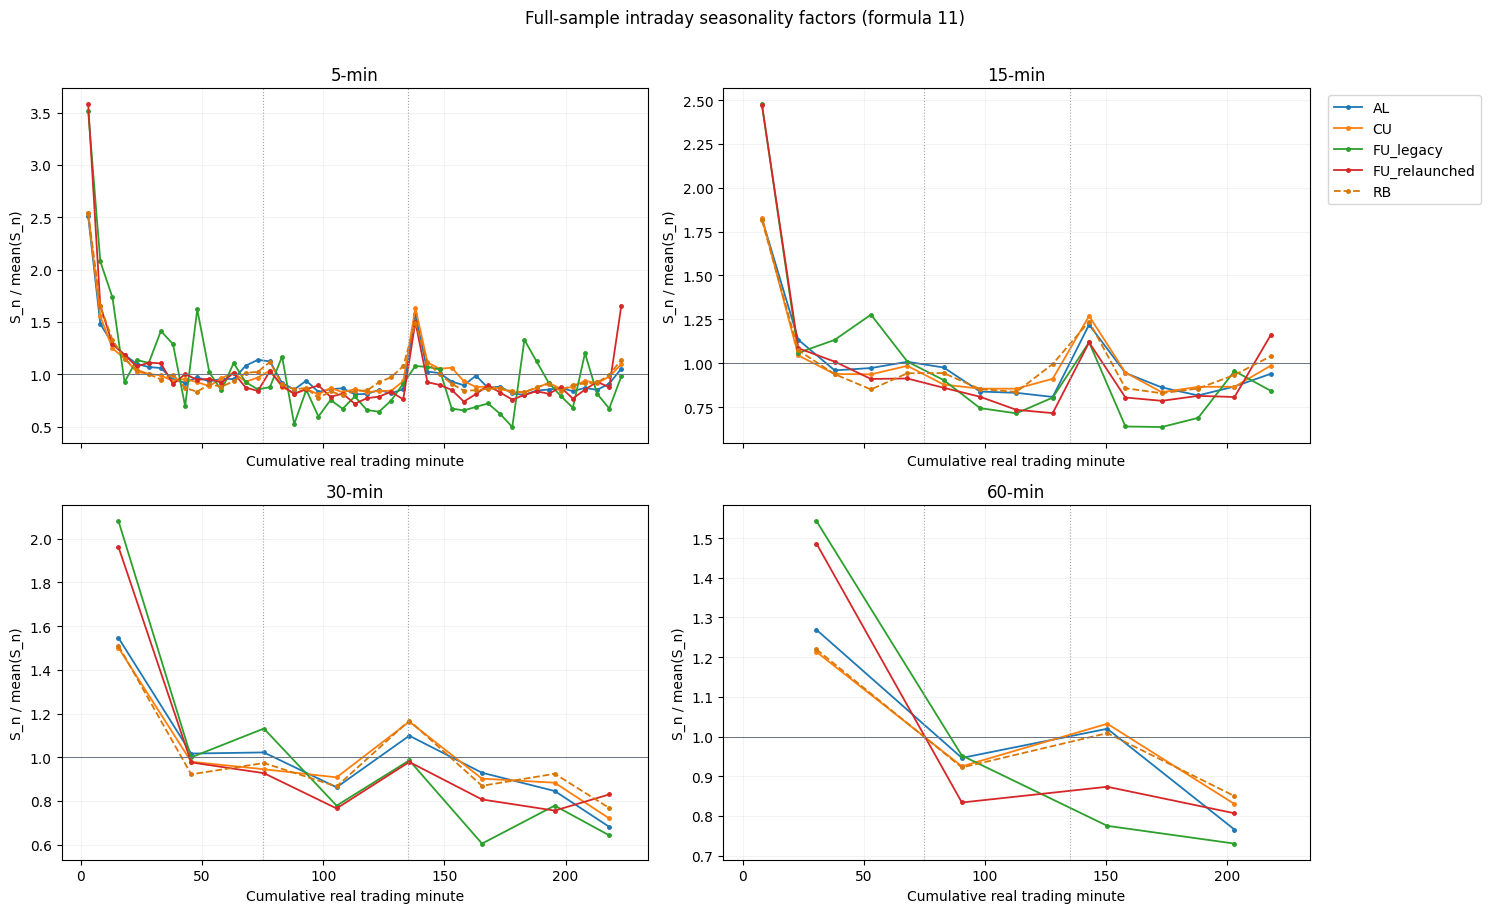

In [12]:
figure, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)

for axis, interval_label in zip(axes.flat, interval_order):
    interval_factor_df = seasonality_factor_df.loc[
        seasonality_factor_df["interval_label"] == interval_label
    ]
    for series_id in series_order:
        series_factor_df = interval_factor_df.loc[
            interval_factor_df["series_id"] == series_id
        ]
        axis.plot(
            series_factor_df["slot_midpoint_trading_minute"],
            series_factor_df["normalized_seasonality_factor"],
            marker="o",
            markersize=2.5,
            linewidth=1.3,
            linestyle="--" if series_id == "RB" else "-",
            color="#d97706" if series_id == "RB" else None,
            label=series_id,
        )
    axis.axvline(75, color="#9ca3af", linewidth=0.8, linestyle=":")
    axis.axvline(135, color="#9ca3af", linewidth=0.8, linestyle=":")
    axis.axhline(1.0, color="#6b7280", linewidth=0.7)
    axis.set_title(interval_label)
    axis.set_xlabel("Cumulative real trading minute")
    axis.set_ylabel("S_n / mean(S_n)")
    axis.grid(alpha=0.15)

axes[0, 1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
figure.suptitle(
    "Full-sample intraday seasonality factors (formula 11)",
    y=1.01,
)
figure.tight_layout()
plt.show()

In [13]:
largest_shape_rows_df = (
    factor_extrema_df.sort_values(
        "peak_to_trough_ratio",
        ascending=False,
    )
    .groupby("series_id", observed=True)
    .head(1)
    .sort_values("series_id")
    .reset_index(drop=True)
)
display(largest_shape_rows_df.round(6))

interpretation_lines = []
for series_id in series_order:
    series_shape = largest_shape_rows_df.loc[
        largest_shape_rows_df["series_id"] == series_id
    ].iloc[0]
    series_sensitivity = historical_sensitivity_df.loc[
        historical_sensitivity_df["series_id"] == series_id
    ]
    interpretation_lines.append(
        f"- **{series_id}**：最强槽位形状出现在 {series_shape['interval_label']}，"
        f"峰谷比 {series_shape['peak_to_trough_ratio']:.2f}；"
        f"严格历史因子相对全文样本因子的稳定期中位绝对差异范围为 "
        f"{series_sensitivity['median_absolute_factor_difference_pct'].min():.2f}%–"
        f"{series_sensitivity['median_absolute_factor_difference_pct'].max():.2f}%。"
    )

display(
    Markdown(
        f"""
## 10. 结果解释

{chr(10).join(interpretation_lines)}

周期曲线反映确定性的槽位尺度，不等同于条件波动预测。全文样本因子用于复现论文；
严格历史因子只用于量化前视敏感性。去季节化不会改变零收益数量，因此不能消除由缺乏成交造成的
高频信息损失。
"""
    )
)

,series_id,interval_label,peak_slot,peak_start_minute,peak_end_minute,peak_factor,normalized_peak_factor,trough_slot,trough_start_minute,trough_end_minute,trough_factor,normalized_trough_factor,peak_to_trough_ratio
0,AL,5-min,1,1,5,0.002557,2.508040,37,181,185,0.000818,0.802599,3.124897
1,CU,5-min,1,1,5,0.002656,2.542695,20,96,100,0.000843,0.807424,3.149143
2,FU_legacy,5-min,1,1,5,0.003837,3.513467,36,176,180,0.000541,0.495412,7.092015
3,FU_relaunched,5-min,1,1,5,0.007181,3.578149,23,111,115,0.001440,0.717391,4.987722
4,RB,5-min,1,1,5,0.004242,2.542074,20,96,100,0.001288,0.771612,3.294496



## 10. 结果解释

- **AL**：最强槽位形状出现在 5-min，峰谷比 3.12；严格历史因子相对全文样本因子的稳定期中位绝对差异范围为 7.45%–8.79%。
- **CU**：最强槽位形状出现在 5-min，峰谷比 3.15；严格历史因子相对全文样本因子的稳定期中位绝对差异范围为 6.64%–9.28%。
- **FU_legacy**：最强槽位形状出现在 5-min，峰谷比 7.09；严格历史因子相对全文样本因子的稳定期中位绝对差异范围为 3.59%–11.39%。
- **FU_relaunched**：最强槽位形状出现在 5-min，峰谷比 4.99；严格历史因子相对全文样本因子的稳定期中位绝对差异范围为 12.13%–13.42%。
- **RB**：最强槽位形状出现在 5-min，峰谷比 3.29；严格历史因子相对全文样本因子的稳定期中位绝对差异范围为 6.07%–6.70%。

周期曲线反映确定性的槽位尺度，不等同于条件波动预测。全文样本因子用于复现论文；
严格历史因子只用于量化前视敏感性。去季节化不会改变零收益数量，因此不能消除由缺乏成交造成的
高频信息损失。


## 11. 独立验证门禁

In [14]:
expected_factor_count = (
    len(series_order)
    * int(interval_spec_df["expected_daily_slots"].sum())
)
expected_return_count = int(
    complete_contract_day_df["is_complete_contract_day"].sum()
    * interval_spec_df["expected_daily_slots"].sum()
)
first_historical_observation_df = (
    historical_factor_df.groupby(
        seasonality_group_key,
        observed=True,
        sort=False,
    )
    .head(1)
)
second_historical_observation_df = (
    historical_factor_df.groupby(
        seasonality_group_key,
        observed=True,
        sort=False,
    )
    .nth(1)
    .reset_index()
)
second_manual_factor_squared_error = (
    second_historical_observation_df[
        "historical_seasonality_factor"
    ] ** 2
    - second_historical_observation_df[
        "prior_squared_return_sum"
    ]
    / second_historical_observation_df[
        "prior_observation_count"
    ]
).abs().max()

factor_observation_audit_df = seasonality_factor_df.merge(
    complete_contract_day_df.groupby(
        "series_id",
        observed=True,
    )["is_complete_contract_day"]
    .sum()
    .rename("expected_factor_observations")
    .reset_index(),
    on="series_id",
    validate="many_to_one",
)
factor_observation_audit_df["observation_difference"] = (
    factor_observation_audit_df["factor_observations"]
    - factor_observation_audit_df["expected_factor_observations"]
)

maximum_unit_rms_deviation = deseasonalization_audit_df[
    "mean_squared_deseasonalized_return"
].sub(1.0).abs().max()
maximum_return_reconstruction_error = seasonal_return_df[
    "return_reconstruction_error"
].abs().max()
maximum_squared_reconstruction_error = seasonal_return_df[
    "squared_return_reconstruction_error"
].abs().max()

fu_legacy_last_date = seasonal_return_df.loc[
    seasonal_return_df["series_id"] == "FU_legacy",
    "trading_date",
].max()
fu_relaunched_first_date = seasonal_return_df.loc[
    seasonal_return_df["series_id"] == "FU_relaunched",
    "trading_date",
].min()

validation_gate_df = pd.DataFrame(
    [
        (
            "latitude_environment",
            current_python == expected_python,
            str(current_python),
        ),
        (
            "source_schema_physical_compatibility",
            source_contract_audit_df[
                "physical_mismatch_count"
            ].eq(0).all(),
            ", ".join(source_contract_audit_df["table_name"]),
        ),
        (
            "unique_trade_month_plus_three_contract",
            contract_mapping_audit_df[
                "target_contract_count"
            ].isin([0, 1]).all()
            and contract_series_df["contract_code"].eq(
                contract_series_df["expected_contract_code"]
            ).all()
            and actual_missing_keys_df.equals(known_missing_keys_df),
            "唯一固定三个月合约；仅排除 22 日 FU1102.XSGE 未上市缺口",
        ),
        (
            "day_sessions_and_minute_alignment",
            not contract_calendar_df["is_night_session"].any()
            and not bar_calendar_df["is_night_session"].any()
            and complete_contract_day_df[
                "is_complete_contract_day"
            ].all()
            and minute_read_audit_df[
                "session_alignment_failures"
            ].eq(0).all(),
            (
                f"{len(complete_contract_day_df):,} 合约日；"
                f"{int(minute_read_audit_df['selected_day_minute_rows'].sum()):,} 日盘分钟"
            ),
        ),
        (
            "intraday_slot_structure",
            slot_audit_df[
                [
                    "slot_count_failures",
                    "aggregated_minute_count_failures",
                    "non_last_slot_length_failures",
                    "last_slot_length_failures",
                ]
            ].eq(0).all().all(),
            "每日 45/15/8/4 槽；30/60 分钟末槽 15/45 分钟",
        ),
        (
            "factor_count_and_observations",
            len(seasonality_factor_df) == expected_factor_count
            and factor_observation_audit_df[
                "observation_difference"
            ].eq(0).all()
            and len(seasonal_return_df) == expected_return_count,
            (
                f"{len(seasonality_factor_df)} 个周期因子；"
                f"{len(seasonal_return_df):,} 个盘中收益"
            ),
        ),
        (
            "factors_finite_and_positive",
            np.isfinite(
                seasonality_factor_df["seasonality_factor"]
            ).all()
            and seasonality_factor_df[
                "seasonality_factor"
            ].gt(0).all(),
            "全部全文样本因子有限且严格为正",
        ),
        (
            "deseasonalized_slot_rms",
            maximum_unit_rms_deviation < 1e-12,
            (
                "每槽 mean(r_tilde^2)=1；"
                f"最大偏差 {maximum_unit_rms_deviation:.3e}"
            ),
        ),
        (
            "return_reseasonalization",
            maximum_return_reconstruction_error < 1e-15,
            f"最大收益重构误差 {maximum_return_reconstruction_error:.3e}",
        ),
        (
            "squared_scale_reseasonalization",
            maximum_squared_reconstruction_error < 1e-17,
            (
                "r_tilde^2 * S_n^2 = r^2；"
                f"最大误差 {maximum_squared_reconstruction_error:.3e}"
            ),
        ),
        (
            "zero_returns_unchanged",
            deseasonalization_audit_df[
                "original_zero_returns"
            ].eq(
                deseasonalization_audit_df[
                    "deseasonalized_zero_returns"
                ]
            ).all(),
            "正因子缩放不改变零收益计数",
        ),
        (
            "strict_history_first_observation",
            first_historical_observation_df[
                "prior_observation_count"
            ].eq(0).all()
            and first_historical_observation_df[
                "historical_seasonality_factor"
            ].isna().all(),
            "每个槽位首个观察无历史因子",
        ),
        (
            "strict_history_manual_formula",
            second_historical_observation_df[
                "prior_observation_count"
            ].eq(1).all()
            and second_manual_factor_squared_error < 1e-18,
            (
                "第二个观察的因子只来自首个观察；"
                f"平方公式最大误差 {second_manual_factor_squared_error:.3e}"
            ),
        ),
        (
            "fu_segments_are_independent",
            fu_legacy_last_date < fu_relaunched_first_date,
            (
                f"legacy_end={fu_legacy_last_date.date()}, "
                f"relaunched_start={fu_relaunched_first_date.date()}"
            ),
        ),
        (
            "rb_extension_is_separate",
            sample_spec_df.loc[
                sample_spec_df["series_id"] == "RB",
                "research_role",
            ].eq("论文外扩展品种").all()
            and "RB" in seasonality_factor_df["series_id"].unique(),
            "RB 单列，不并入论文品种标签",
        ),
    ],
    columns=["gate", "passed", "evidence"],
)
display(factor_observation_audit_df)
display(validation_gate_df)
assert validation_gate_df["passed"].all(), validation_gate_df.loc[
    ~validation_gate_df["passed"]
]

,series_id,interval_label,interval_slot,factor_observations,mean_squared_return,target_interval_minutes,minimum_actual_minutes,maximum_actual_minutes,seasonality_factor,normalized_seasonality_factor,slot_start_trading_minute,slot_end_trading_minute,slot_midpoint_trading_minute,expected_factor_observations,observation_difference
0,AL,5-min,1,4045,0.000007,5,5,5,0.002557,2.508040,1,5,3.0,4045,0
1,AL,5-min,2,4045,0.000002,5,5,5,0.001510,1.480896,6,10,8.0,4045,0
2,AL,5-min,3,4045,0.000002,5,5,5,0.001318,1.293022,11,15,13.0,4045,0
3,AL,5-min,4,4045,0.000001,5,5,5,0.001209,1.185433,16,20,18.0,4045,0
4,AL,5-min,5,4045,0.000001,5,5,5,0.001122,1.099957,21,25,23.0,4045,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,RB,30-min,8,4045,0.000008,30,15,15,0.002879,0.767726,211,225,218.0,4045,0
356,RB,60-min,1,4045,0.000042,60,60,60,0.006500,1.219543,1,60,30.5,4045,0
357,RB,60-min,2,4045,0.000024,60,60,60,0.004914,0.921994,61,120,90.5,4045,0
358,RB,60-min,3,4045,0.000029,60,60,60,0.005375,1.008457,121,180,150.5,4045,0


,gate,passed,evidence
0,latitude_environment,True,E:\anaconda3\envs\latitude\python.exe
1,source_schema_physical_compatibility,True,"dim_futures_variety_calendar, dim_futures_contract_calendar, dim_futures_bar_calendar, fact_futures_minute"
2,unique_trade_month_plus_three_contract,True,唯一固定三个月合约；仅排除 22 日 FU1102.XSGE 未上市缺口
3,day_sessions_and_minute_alignment,True,"14,153 合约日；3,184,425 日盘分钟"
4,intraday_slot_structure,True,每日 45/15/8/4 槽；30/60 分钟末槽 15/45 分钟
5,factor_count_and_observations,True,"360 个周期因子；1,019,016 个盘中收益"
6,factors_finite_and_positive,True,全部全文样本因子有限且严格为正
7,deseasonalized_slot_rms,True,每槽 mean(r_tilde^2)=1；最大偏差 4.441e-16
8,return_reseasonalization,True,最大收益重构误差 1.388e-17
9,squared_scale_reseasonalization,True,r_tilde^2 * S_n^2 = r^2；最大误差 1.735e-18


## 12. 结果解释边界与限制

1. 公式 (11) 的全文样本因子故意使用整个样本，包括相对早期观察而言的未来数据；它只作为论文复现基线，不能伪装成实时可得估计。
2. 严格历史敏感性使用同槽位此前全部观察，不设滚动窗；“至少 60 个先前观察”只定义稳定差异报告，不授权未来预测批次。
3. 公式 (11) 使用未去均值的平方收益均值，严格依照论文；不另行扣除槽位均值，也不将因子标准化后输入模型。
4. 30、60 分钟末槽时长较短；因子同时吸收时长与时段效应，不能将末槽差异完全解释为纯粹的交易时钟季节性。
5. 去季节化只调整非零收益的尺度，不改变零收益数量；微观流动性问题仍需由模型结果和预测比较单独评估。
6. 本项验证平方尺度恒等式，但没有估计条件方差模型；公式 (13) 的实际预测重新季节化留给后续滚动预测 Notebook。
7. FU 两段独立估计因子；RB 的曲线和敏感性结论不能并入论文原品种结论。
8. 后续 Notebook 必须在自身重算收益与季节因子，不读取本 Notebook 的内存对象或持久化中间产物。